<a href="https://colab.research.google.com/github/plnu-biomechanics/kin6015/blob/main/notebooks/kin6015_pilot_data_arryn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pointloma.edu/sites/default/files/styles/basic_page/public/images/PLNU_Biomechanics_Lab_green_yellowSD_HiRes.png" width=400>

## **KIN 6015 Biomechanical Basis of Human Movement**
Instructor: Arnel Aguinaldo, PhD

**Pilot Data Ingestion**

This is a template you can use to work on your team pilot. Inverse kinematics (IK) and kinetics via inverse dynamics as well as rectified EMG were estimated using Visual3D. The data were then exported as text (*.txt) files and uploaded to the class repository in the lab's [GitHub](https://github.com/plnu-biomechanics). There is only one code cell in this notebook as each team's pilot dataset is different so you will need to refer back to previous labs and use GenAI to write your own code to parse and analyze the data.

### Create your own Colab Notebook

1. Go to **File -> New notebook in Drive** to open a new notebook in your Python environment:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/file_notebook.png" width=450>

2. Rename your Colab notebook using this naming format: **lastname_group_lab#.ipynb** (e.g., "aguinaldo_targaryen_lab1.ipynb")
3. Click on the **+ Code** option above to insert a new code cell: <br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/addcode.png" width=280>

4. The data you will parse and analyze for this lab will be copied from the lab's GitHub and temporarily stored in your Colab's runtime directory, which can be accessed by clicking on the folder icon in the left menu:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/colab_folder.png" width=400>

5. Copy the following lines of code to import the packages needed for this analysis and to load the data files into your working directory. Be sure to update the `GROUP` variable with your group's name. **Note**: These files are "runtime" access only, meaning they are only temporarily stored in your working directory and show up when your notebook is in session. However, the following code cell allows you to clone the zipped files to the working directory each time it is executed.


In [1]:
import urllib.request
import urllib.error
import zipfile
import os

# --------------------------------------------------
# STUDENT INPUT (edit only this line; case-sensitive)
# --------------------------------------------------
GROUP = "arryn"   # e.g., "targaryen", "stark", "lannister", "martell", "greyjoy"

# --------------------------------------------------
# Configuration (do NOT edit below)
# These lines create a directory for this lab in your
# Colab working directory.
# --------------------------------------------------
zip_dir = "kin6015/pilot"
os.makedirs(zip_dir, exist_ok=True)

zip_filename = f"spring2026_pilot_{GROUP}.zip"

url = (
    "https://raw.githubusercontent.com/"
    "plnu-biomechanics/kin6015/main/"
    f"labs/{zip_filename}"
)

zip_path = os.path.join(zip_dir, zip_filename)

download_successful = False
# --------------------------------------------------
# Download zip file with existence check
# --------------------------------------------------
try:
    with urllib.request.urlopen(url) as response:
        if response.getcode() == 200:
            print(f"Downloading {zip_filename}...")
            urllib.request.urlretrieve(url, zip_path)
            download_successful = True
        else:
            print(f"Error: Could not retrieve {zip_filename}. Status code: {response.getcode()}")
            print(f"Please ensure the GROUP variable ('{GROUP}') is correct and a corresponding zip file exists at: {url}")
except urllib.error.HTTPError as e:
    if e.code == 404:
        print(f"Error: The zip file '{zip_filename}' was not found at the specified URL.")
        print(f"Please check the 'GROUP' variable ('{GROUP}') and ensure a corresponding file exists in the GitHub repository: {url}")
    else:
        print(f"An HTTP error occurred: {e}")
except urllib.error.URLError as e:
    print(f"A URL error occurred (e.g., network issue): {e}")

# --------------------------------------------------
# Extract contents from the zipped file only if download was successful
# --------------------------------------------------
if download_successful:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(zip_dir)

    print("Extracted files in lab directory:")
    print(os.listdir(zip_dir))
else:
    print("File download failed, skipping extraction.")


Extracted files in lab directory:
['Arryn_Incline-R_05.txt', 'spring2026_pilot_arryn.zip', 'Arryn_Incline-R_03.txt', 'Arryn_Incline-L_03.txt', 'Arryn_Incline-L_01.txt', 'Arryn_Flat_03.txt', 'Arryn_Incline-L_05.txt', 'Arryn_Incline-R_04.txt', 'Arryn_Incline-R_02.txt', 'Arryn_Flat_01.txt', 'Arryn_Incline-L_02.txt', 'Arryn_Flat_04.txt', 'Arryn_Incline-R_01.txt', 'Arryn_Incline-L_04.txt', 'Arryn_Flat_05.txt', 'Arryn_Flat_02.txt']


In [2]:
import pandas as pd
import os
import re # Import the regular expression module

def parse_txt_file(filepath):
  """Reads a text file, extracts variable names and time-series data, identifies the condition,
  and returns a pandas DataFrame.

  Args:
    filepath (str): The full path to the text file.

  Returns:
    pd.DataFrame: A DataFrame containing the extracted data, condition, and filename.
  """
  with open(filepath, 'r') as file:
    lines = file.readlines()

  # Check if file has enough lines for the expected structure
  if len(lines) < 6: # Need at least 6 lines (5 header, 1 data)
      raise ValueError(f"File {os.path.basename(filepath)} has too few lines to parse correctly.")

  # Extract variable names from the 2nd line (index 1), using tab as delimiter
  variable_names = lines[1].strip().split('\t')

  # Read time-series data starting from the 6th line (index 5), using tab as delimiter
  data_lines = [line.strip().split('\t') for line in lines[5:] if line.strip()]

  # Ensure data_lines is not empty before checking lengths
  if not data_lines:
      raise ValueError(f"No data found in file {os.path.basename(filepath)} after header.")

  # Dynamically add 'Frame' if data rows have one more column than variable names
  if len(data_lines[0]) == len(variable_names) + 1:
      variable_names.insert(0, 'Frame')

  # Ensure variable names and data lines match in length AFTER potential adjustment
  if len(variable_names) != len(data_lines[0]):
      raise ValueError(f"Column name count ({len(variable_names)}) does not match data column count ({len(data_lines[0])}) in file {os.path.basename(filepath)}.")

  # Create DataFrame
  df = pd.DataFrame(data_lines, columns=variable_names)

 # Remove '_MEAN' suffixes from column names
  new_columns = []
  for col in df.columns:
      new_col = re.sub(r'_MEAN', '', col)
      new_columns.append(new_col)
  df.columns = new_columns

    # Rename 'MAX_R_GRF_MEAN' to 'Vertical GRF' if it exists
  if 'GRFz' in df.columns:
    df = df.rename(columns={'GRFz': 'Vertical_GRF'})

  # Convert numeric columns to appropriate data types
  for col in df.columns:
    try:
      df[col] = pd.to_numeric(df[col])
    except ValueError:
      pass # Keep as string if not numeric

  # Determine 'condition' from filename
  filename = os.path.basename(filepath)
  if 'Flat' in filename:
    condition = 'Flat'
  elif 'Incline-L' in filename:
    condition = 'Incline-L'
  elif 'Incline-R' in filename:
    condition = 'Incline-R'
  else:
    condition = 'unknown'

  # Add 'condition' column
  df['condition'] = condition

  # Add 'filename' column
  df['filename'] = filename

  return df

print("Updated function 'parse_txt_file' to handle tab-delimited data, correct line indexing, dynamic 'Frame' column, case-sensitive condition check, import 're' module, rename 'Right Ankle Angles' column, and remove '_MEAN'/'_Mean' suffixes.")


# 1. Get the list of .txt files from the working directory
zip_dir = "kin6015/pilot"
all_files = os.listdir(zip_dir)
txt_files = [f for f in all_files if f.endswith('.txt')]

# 2. Initialize an empty list to store DataFrames
all_dataframes = []

# 3. Iterate through each .txt file and apply the parse_txt_file function
for filename in txt_files:
    filepath = os.path.join(zip_dir, filename)
    try:
        df = parse_txt_file(filepath)
        all_dataframes.append(df)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

# 4. Concatenate all DataFrames into a single combined_intermediate_df
if all_dataframes:
    combined_intermediate_df = pd.concat(all_dataframes, ignore_index=True)
    print("Combined_intermediate_df created successfully.")
else:
    combined_intermediate_df = pd.DataFrame()
    print("No dataframes to concatenate, combined_intermediate_df is empty.")


# 5. Create timeseries_df
timeseries_df = combined_intermediate_df[
    [
        'Frame',
        'L_QUAD',
        'L_HAMSTRING',
        'L_GASTROC',
        'R_QUAD',
        'R_HAMSTRING',
        'condition',
        'filename'
        ]
    ]

# 6. Create discretes_df
discretes_df = combined_intermediate_df[combined_intermediate_df['Frame'] == 1][
    [
        'filename',
        'condition',
        'Left GRF_MAX',
        'Left Hip Angles_MAX',
        'Left Knee Angles_MAX',
        'Right GRF_MAX',
        'Right Hip Angles_MAX',
        'Right Knee Angles_MAX',
        'Left_Stride_Length',
        'Right_Stride_Length'
        ]
    ]

# 7. Display the head of timeseries_df
print("\nHead of timeseries_df:")
print(timeseries_df.head())

# 8. Display the head of discretes_df
print("\nHead of discretes_df:")
print(discretes_df.head())

Updated function 'parse_txt_file' to handle tab-delimited data, correct line indexing, dynamic 'Frame' column, case-sensitive condition check, import 're' module, rename 'Right Ankle Angles' column, and remove '_MEAN'/'_Mean' suffixes.
Combined_intermediate_df created successfully.

Head of timeseries_df:
   Frame   L_QUAD  L_HAMSTRING  L_GASTROC   R_QUAD  R_HAMSTRING  condition  \
0      1  2.99355     14.79874    7.87671  4.34257      5.61320  Incline-R   
1      2  2.65552     15.27143    7.62548  4.47508      5.35164  Incline-R   
2      3  2.81851     16.21189    7.82505  4.64979      5.14962  Incline-R   
3      4  2.72060     16.58261    8.04574  4.99874      5.15626  Incline-R   
4      5  2.92507     16.54898   10.42993  5.25901      4.00742  Incline-R   

                 filename  
0  Arryn_Incline-R_05.txt  
1  Arryn_Incline-R_05.txt  
2  Arryn_Incline-R_05.txt  
3  Arryn_Incline-R_05.txt  
4  Arryn_Incline-R_05.txt  

Head of discretes_df:
                   filename  cond

In [4]:
import numpy as np

# ================
# DATA WRANGLING
# =================

# This code chunk wrangles time-series data into respective arrays for SPM analysis

# Recreate timeseries_df with .copy() to avoid SettingWithCopyWarning
timeseries_df = combined_intermediate_df[
    [
        'Frame',
        'L_QUAD',
        'L_HAMSTRING',
        'L_GASTROC',
        'R_QUAD',
        'R_HAMSTRING',
        'condition',
        'filename'
        ]
    ].copy()

# Add 'trial_id' column by cleaning the 'filename'
timeseries_df['trial_id'] = timeseries_df['filename'].str.replace('_Flat', '', regex=False)
timeseries_df['trial_id'] = timeseries_df['trial_id'].str.replace('_Incline-L', '', regex=False)
timeseries_df['trial_id'] = timeseries_df['trial_id'].str.replace('_Incline-R', '', regex=False)
timeseries_df['trial_id'] = timeseries_df['trial_id'].str.replace('.txt', '', regex=False)

print("Head of timeseries_df with new 'trial_id' column:")
display(timeseries_df)

print("\nUnique trial IDs:")
print(timeseries_df.head())

print("\nUnique trial IDs:")
print(timeseries_df['trial_id'].unique())

# Filter for all conditions
flat_df = timeseries_df[timeseries_df['condition'] == 'Flat']
incline_left_df = timeseries_df[timeseries_df['condition'] == 'Incline-L']
incline_right_df = timeseries_df[timeseries_df['condition'] == 'Incline-L']

# ------- L QUAD -------

# Prepare data for L Quad EMG (flat)
L_quad_flat_data = flat_df.pivot(index='trial_id', columns='Frame', values='L_QUAD').values

# Prepare data for L Quad EMG (incline-left)
L_quad_incline_left_data = incline_left_df.pivot(index='trial_id', columns='Frame', values='L_QUAD').values

# Prepare data for L Quad EMG (incline-right)
L_quad_incline_right_data = incline_right_df.pivot(index='trial_id', columns='Frame', values='L_QUAD').values

# ------- L HAMSTRING -------

# Prepare data for L Hamstring EMG (flat)
L_hamstring_flat_data = flat_df.pivot(index='trial_id', columns='Frame', values='L_HAMSTRING').values

# Prepare data for L Hamstring EMG (incline-left)
L_hamstring_incline_left_data = incline_left_df.pivot(index='trial_id', columns='Frame', values='L_HAMSTRING').values

# Prepare data for L Hamstring EMG (incline-right)
L_hamstring_incline_right_data = incline_right_df.pivot(index='trial_id', columns='Frame', values='L_HAMSTRING').values

# ------- L GASTROC -------

# Prepare data for L GASTROC EMG (flat)
L_gastroc_flat_data = flat_df.pivot(index='trial_id', columns='Frame', values='L_GASTROC').values

# Prepare data for L GASTROC EMG (incline-left)
L_gastroc_incline_left_data = incline_left_df.pivot(index='trial_id', columns='Frame', values='L_GASTROC').values

# Prepare data for L GASTROC EMG (incline-right)
L_gastroc_incline_right_data = incline_right_df.pivot(index='trial_id', columns='Frame', values='L_GASTROC').values

# ------- R QUAD -------

# Prepare data for R Quad EMG (flat)
R_quad_flat_data = flat_df.pivot(index='trial_id', columns='Frame', values='R_QUAD').values

# Prepare data for R Quad EMG (incline-left)
R_quad_incline_left_data = incline_left_df.pivot(index='trial_id', columns='Frame', values='R_QUAD').values

# Prepare data for R Quad EMG (incline-right)
R_quad_incline_right_data = incline_right_df.pivot(index='trial_id', columns='Frame', values='R_QUAD').values

# ------- R HAMSTRING -------

# Prepare data for R Hamstring EMG (flat)
R_hamstring_flat_data = flat_df.pivot(index='trial_id', columns='Frame', values='R_HAMSTRING').values

# Prepare data for R Hamstring EMG (incline-left)
R_hamstring_incline_left_data = incline_left_df.pivot(index='trial_id', columns='Frame', values='R_HAMSTRING').values

# Prepare data for R Hamstring EMG (incline-right)
R_hamstring_incline_right_data = incline_right_df.pivot(index='trial_id', columns='Frame', values='R_HAMSTRING').values

print(f"L_quad_flat_data shape: {L_quad_flat_data.shape}")
print(f"L_quad_incline_left_data shape: {L_quad_incline_left_data.shape}")
print(f"L_quad_incline_right_data shape: {L_quad_incline_right_data.shape}")
print(f"L_hamstring_flat_data shape: {L_hamstring_flat_data.shape}")
print(f"L_hamstring_incline_left_data shape: {L_hamstring_incline_left_data.shape}")
print(f"L_hamstring_incline_right_data shape: {L_hamstring_incline_right_data.shape}")
print(f"L_gastroc_flat_data shape: {L_gastroc_flat_data.shape}")
print(f"L_gastroc_incline_left_data shape: {L_gastroc_incline_left_data.shape}")
print(f"L_gastroc_incline_right_data shape: {L_gastroc_incline_right_data.shape}")
print(f"R_quad_flat_data shape: {R_quad_flat_data.shape}")
print(f"R_quad_incline_left_data shape: {R_quad_incline_left_data.shape}")
print(f"R_quad_incline_right_data shape: {R_quad_incline_right_data.shape}")
print(f"R_hamstring_flat_data shape: {R_hamstring_flat_data.shape}")
print(f"R_hamstring_incline_left_data shape: {R_hamstring_incline_left_data.shape}")
print(f"R_hamstring_incline_right_data shape: {R_hamstring_incline_right_data.shape}")


Head of timeseries_df with new 'trial_id' column:


,Frame,L_QUAD,L_HAMSTRING,L_GASTROC,R_QUAD,R_HAMSTRING,condition,filename,trial_id
0,1,2.99355,14.79874,7.87671,4.34257,5.61320,Incline-R,Arryn_Incline-R_05.txt,Arryn_05
1,2,2.65552,15.27143,7.62548,4.47508,5.35164,Incline-R,Arryn_Incline-R_05.txt,Arryn_05
2,3,2.81851,16.21189,7.82505,4.64979,5.14962,Incline-R,Arryn_Incline-R_05.txt,Arryn_05
3,4,2.72060,16.58261,8.04574,4.99874,5.15626,Incline-R,Arryn_Incline-R_05.txt,Arryn_05
4,5,2.92507,16.54898,10.42993,5.25901,4.00742,Incline-R,Arryn_Incline-R_05.txt,Arryn_05
...,...,...,...,...,...,...,...,...,...
1510,97,5.14372,12.31318,9.37872,2.72356,4.40507,Flat,Arryn_Flat_02.txt,Arryn_02
1511,98,4.25413,11.37146,9.43692,2.85182,4.33789,Flat,Arryn_Flat_02.txt,Arryn_02
1512,99,4.24971,11.21618,9.29078,2.99594,4.73379,Flat,Arryn_Flat_02.txt,Arryn_02
1513,100,4.27096,9.65131,8.67366,3.08653,4.49681,Flat,Arryn_Flat_02.txt,Arryn_02



Unique trial IDs:
   Frame   L_QUAD  L_HAMSTRING  L_GASTROC   R_QUAD  R_HAMSTRING  condition  \
0      1  2.99355     14.79874    7.87671  4.34257      5.61320  Incline-R   
1      2  2.65552     15.27143    7.62548  4.47508      5.35164  Incline-R   
2      3  2.81851     16.21189    7.82505  4.64979      5.14962  Incline-R   
3      4  2.72060     16.58261    8.04574  4.99874      5.15626  Incline-R   
4      5  2.92507     16.54898   10.42993  5.25901      4.00742  Incline-R   

                 filename  trial_id  
0  Arryn_Incline-R_05.txt  Arryn_05  
1  Arryn_Incline-R_05.txt  Arryn_05  
2  Arryn_Incline-R_05.txt  Arryn_05  
3  Arryn_Incline-R_05.txt  Arryn_05  
4  Arryn_Incline-R_05.txt  Arryn_05  

Unique trial IDs:
['Arryn_05' 'Arryn_03' 'Arryn_01' 'Arryn_04' 'Arryn_02']
L_quad_flat_data shape: (5, 101)
L_quad_incline_left_data shape: (5, 101)
L_quad_incline_right_data shape: (5, 101)
L_hamstring_flat_data shape: (5, 101)
L_hamstring_incline_left_data shape: (5, 101)
L_hamstr

/tmp/ipykernel_1327/36225500.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)
/tmp/ipykernel_1327/36225500.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)


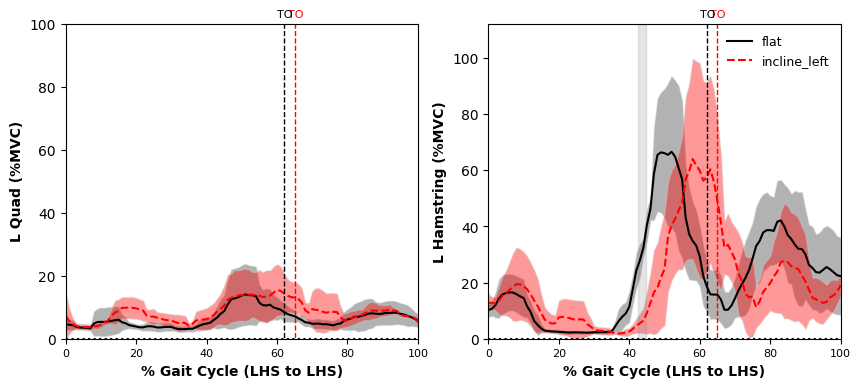

In [11]:
!pip install spm1d

import spm1d
import numpy as np
import matplotlib.pyplot as pyplot

total_frames = 101
num_ticks = 6  # Number of ticks (0%, 10%, ..., 100%)

# Define a function to create each plot
def plot_spm(ax, Y1, Y2, label_Y1, label_Y2, x_label, y_label, y_limits, units, color_Y1, color_Y2, show_legend):
    spm1d.plot.plot_mean_sd(Y1, label=label_Y1, linecolor=color_Y1, facecolor=color_Y1, ax=ax, lw=1.5, alpha=0.3, autoset_ylim=False)
    spm1d.plot.plot_mean_sd(Y2, label=label_Y2, linecolor=color_Y2, facecolor=color_Y2, linestyle='--', lw=1.5, alpha=0.4, ax=ax, autoset_ylim=False)
    ax.axhline(y=0, color='k', linestyle=':')

    # --- Start of fix for zero variance error ---
    # Check for zero variance in Y1 and Y2 at each node and add tiny noise if variance is zero
    Y1_copy = Y1.copy() # Create copies to avoid modifying original global arrays directly
    Y2_copy = Y2.copy()
    for i in range(Y1_copy.shape[1]): # Iterate through each node (column)
        if np.var(Y1_copy[:, i]) == 0:
            Y1_copy[:, i] += np.random.rand(Y1_copy.shape[0]) * 1e-9 # Add tiny noise if variance is zero
        if np.var(Y2_copy[:, i]) == 0:
            Y2_copy[:, i] += np.random.rand(Y2_copy.shape[0]) * 1e-9 # Add tiny noise if variance is zero
    # --- End of fix ---

    # Conduct t-test (using ttest_paired for paired comparison):
    alpha      = 0.05
    t          = spm1d.stats.ttest_paired(Y1_copy, Y2_copy) # Pass Y1_copy and Y2_copy separately
    ti         = t.inference(alpha, two_tailed=True, interp=True)

    # Highlight suprathreshold regions
    for cluster in ti.clusters:
        start, end = cluster.endpoints
        ax.axvspan(start, end, ymin=0, ymax=1.0, color='grey', alpha=0.20)

    # Generate plots
    percentages = np.linspace(0, 100, num_ticks)  # 0%, 10%, ..., 100%
    x_ticks = (percentages / 100) * total_frames  # Normalize frame numbers
    ypos = y_limits[1] + y_limits[1]*.02          # event labels
    ax.set_xticklabels(percentages.astype(int), fontsize=8)  # Set labels as integers (0, 10%, ..., 100%)
    # ax.set_xticks(x_ticks)
    ax.vlines(x=65, ymin=y_limits[0]-100, ymax=y_limits[1]+100, color='r', linestyle='--', lw=1)
    ax.text(63, ypos, 'TO', fontsize=8, color='r')
    ax.vlines(x=62, ymin=y_limits[0]-100, ymax=y_limits[1]+100, color='k', linestyle='--', lw=1)
    ax.text(60, ypos, 'TO', fontsize=8)
    ax.set_xlabel(x_label, fontsize=10, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=10, fontweight='bold') if y_label else ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.set_ylim(y_limits)

    if show_legend:
      ax.legend(fontsize=9, loc='upper right', frameon=False)

# Combine both SPM plots (no SPM{t} fields)
pyplot.figure( figsize=(10, 9) ) # Adjusted figsize for a 4 plot grid

# =============================================================================
# L QUAD
# =============================================================================

# Replace x and y axes and filename label
xlabel = "% Gait Cycle (LHS to LHS)"
ylabel="L Quad"
units = "%MVC"

# YA (black)
YA            = L_quad_flat_data

# YB (red)
YB            = L_quad_incline_left_data

# Calculate shared y-axis limits
all_data_for_y_limits = np.concatenate((YA.flatten(), YB.flatten()))
all_data_for_y_limits = all_data_for_y_limits[~np.isnan(all_data_for_y_limits)] # remove NaNs

if len(all_data_for_y_limits) > 0:
    min_val = np.min(all_data_for_y_limits)
    max_val = np.max(all_data_for_y_limits)
    if min_val > 0:
        min_val = 0
else: # If all data is NaN after concatenation and filtering
    min_val = -1.0 # Default to some reasonable range if all data is NaN
    max_val = 1.0
max_val = 100
y_limits = [min_val, max_val]

# Subplot 1
ax1 = pyplot.subplot(2, 2, 1) # Changed to 1 row, 3 columns, position 1
plot_spm(
    ax1, YA, YB,
    label_Y1="Flat",
    label_Y2="Incline_left",
    x_label = xlabel,
    y_label=f'{ylabel} ({units})',
    y_limits=y_limits,
    units=units,
    color_Y1='k',
    color_Y2='r',
    show_legend=False
)

# =============================================================================
# L HAMSTRING
# =============================================================================

# Replace x and y axes and filename label
# xlabel = "% Gait Cycle (LHS to LHS)"
ylabel="L Hamstring"
units = "%MVC"

# YA (black)
YA            = L_hamstring_flat_data

# YB (red)
YB            = L_hamstring_incline_left_data

# Calculate shared y-axis limits
all_data_for_y_limits = np.concatenate((YA.flatten(), YB.flatten()))
all_data_for_y_limits = all_data_for_y_limits[~np.isnan(all_data_for_y_limits)] # remove NaNs

if len(all_data_for_y_limits) > 0:
    min_val = np.min(all_data_for_y_limits)
    max_val = np.max(all_data_for_y_limits)
    if min_val > 0:
        min_val = 0
else: # If all data is NaN after concatenation and filtering
    min_val = -1.0 # Default to some reasonable range if all data is NaN
    max_val = 1.0

# min_val = 0 # Removed hardcoded limits
# max_val = 1000 # Removed hardcoded limits
y_limits = [min_val, max_val] # Use dynamically calculated limits

# Subplot 2
ax2 = pyplot.subplot(2, 2, 2) # Changed to 1 row, 3 columns, position 2
plot_spm(
    ax2, YA, YB,
    label_Y1="flat",
    label_Y2="incline_left",
    x_label = xlabel,
    y_label=f'{ylabel} ({units})',
    y_limits=y_limits,
    units=units,
    color_Y1='k',
    color_Y2='r',
    show_legend=True
)

